# Import Libraries
--------------------------------

In [1]:
import pandas as pd
import numpy as np
import ast
import pickle
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import normalize, StandardScaler, LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, r2_score,
                             classification_report,
                             confusion_matrix, accuracy_score)
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Load Datasets
-----------------------------------------------------------------

In [2]:
# LOAD DATASETS --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
movies = pd.read_csv(r"C:\Users\yashr\MRS\System\dataset\tmdb_5000_movies.csv")
credits = pd.read_csv(r"C:\Users\yashr\MRS\System\dataset\tmdb_5000_credits.csv")

movies_raw = movies.copy() # raw copy for regression, decision tree, etc.....

print(f"Movies shape:  {movies.shape}")
print(f"Credits shape: {credits.shape}")
# =======================================================================================================================================================================================

# MERGE & SELECT COLUMNS ----------------------------------------------------------------------------------------------------------------------------------------------------------------
print("Merging and Selecting Columns")

movies = movies.merge(credits, on = 'title')

print(f"After merge shape: {movies.shape}")

movies = movies[['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew']]
# =======================================================================================================================================================================================

# HANDLE MISSING VALUES -----------------------------------------------------------------------------------------------------------------------------------------------------------------
print("Missing before:\n", movies.isnull().sum())

movies.dropna(inplace=True)
print("Missing after:\n",  movies.isnull().sum())

# =======================================================================================================================================================================================

# PREPROCESS JSON COLUMNS ---------------------------------------------------------------------------------------------------------------------------------------------------------------

print("Preprocessing JSON Columns")

def extract_names(text):
    try:
        return [item['name'] for item in ast.literal_eval(text)]
    except:
        return []

def extract_cast(text):
    try:
        return [item['name'] for item in ast.literal_eval(text)[:3]]
    except:
        return []

def extract_director(text):
    try:
        return [item['name'] for item in ast.literal_eval(text)
                if item['job'] == 'Director']
    except:
        return []

movies['genres']   = movies['genres'].apply(extract_names)
movies['keywords'] = movies['keywords'].apply(extract_names)
movies['cast']     = movies['cast'].apply(extract_cast)
movies['crew']     = movies['crew'].apply(extract_director)
movies['overview'] = movies['overview'].apply(lambda x: x.split())

print("Sample processed row:")
print(movies[['title', 'genres', 'cast', 'crew']].head())
# =======================================================================================================================================================================================
#                                                                                  ****************

Movies shape:  (4803, 20)
Credits shape: (4803, 4)
Merging and Selecting Columns
After merge shape: (4809, 23)
Missing before:
 movie_id    0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64
Missing after:
 movie_id    0
title       0
overview    0
genres      0
keywords    0
cast        0
crew        0
dtype: int64
Preprocessing JSON Columns
Sample processed row:
                                      title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre   
3                     The Dark Knight Rises   
4                               John Carter   

                                          genres  \
0  [Action, Adventure, Fantasy, Science Fiction]   
1                   [Adventure, Fantasy, Action]   
2                     [Action, Adventure, Crime]   
3               [Action, Crime, Drama, Thriller]   
4           [Action, Adventure, Science Fi

# Feature Engineering
----------------------------------

In [3]:
print("Feature Engineering — Creating Tags")

def remove_spaces(lst):
    return [item.replace(" ", "") for item in lst]

movies['genres']   = movies['genres'].apply(remove_spaces)
movies['keywords'] = movies['keywords'].apply(remove_spaces)
movies['cast']     = movies['cast'].apply(remove_spaces)
movies['crew']     = movies['crew'].apply(remove_spaces)

movies['tags'] = (movies['overview'] + movies['genres'] +
                  movies['keywords'] + movies['cast'] + movies['crew'])

movies['tags'] = movies['tags'].apply(lambda x: " ".join(x).lower())

final_df = movies[['movie_id','title','tags']].copy()

print("Tags created successfully!")
print(f"Sample tag: {final_df['tags'][0][:100]}...")



Feature Engineering — Creating Tags
Tags created successfully!
Sample tag: in the 22nd century, a paraplegic marine is dispatched to the moon pandora on a unique mission, but ...


# DISCRETIZATION
-------------------------------------

Discretization
                                      title budget_category rating_category  \
0                                    Avatar            High            Good   
1  Pirates of the Caribbean: At World's End            High         Average   
2                                   Spectre            High         Average   
3                     The Dark Knight Rises            High            Good   
4                               John Carter            High         Average   

  runtime_category  
0             Long  
1             Long  
2             Long  
3             Long  
4             Long  


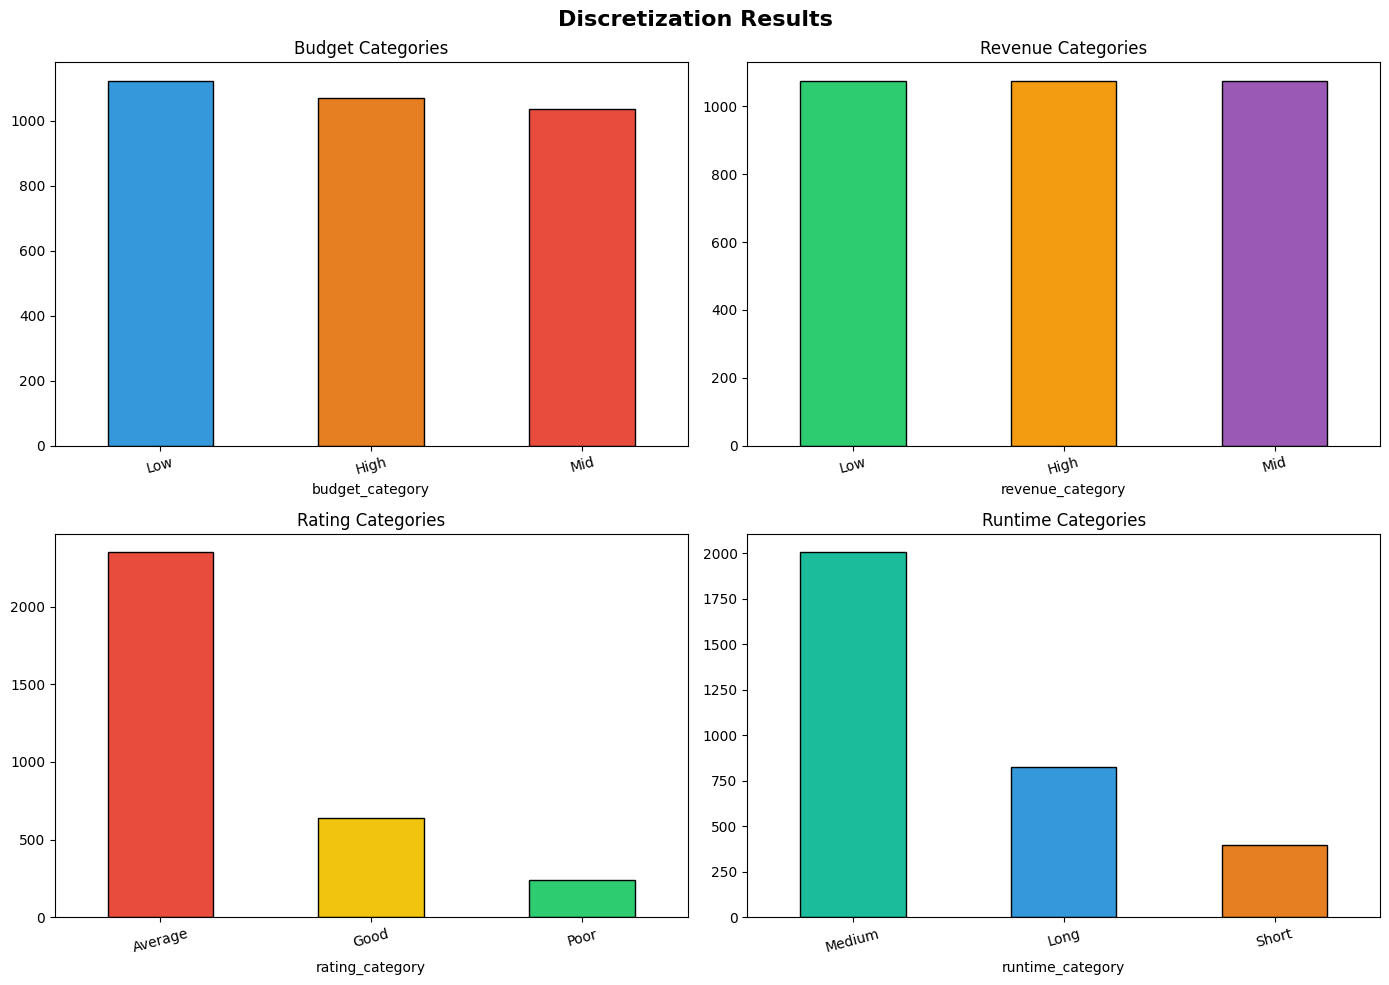

Discretization chart saved!


In [4]:
print("Discretization")

movies_disc = movies_raw[
    (movies_raw['budget']       > 0) &
    (movies_raw['revenue']      > 0) &
    (movies_raw['vote_average'] > 0)
].copy()

movies_disc['budget_category']  = pd.qcut(movies_disc['budget'],
                                           q=3,
                                           labels=['Low','Mid','High'])
movies_disc['revenue_category'] = pd.qcut(movies_disc['revenue'],
                                           q=3,
                                           labels=['Low','Mid','High'])
movies_disc['rating_category']  = pd.cut(movies_disc['vote_average'],
                                          bins=[0, 5.0, 7.0, 10.0],
                                          labels=['Poor','Average','Good'])
movies_disc['runtime_category'] = pd.cut(movies_disc['runtime'],
                                          bins=[0, 90, 120, 300],
                                          labels=['Short','Medium','Long'])

print(movies_disc[['title','budget_category',
                   'rating_category','runtime_category']].head(5))

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Discretization Results', fontsize=16, fontweight='bold')

movies_disc['budget_category'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=['#3498db','#e67e22','#e74c3c'],
    edgecolor='black', title='Budget Categories')
movies_disc['revenue_category'].value_counts().plot(
    kind='bar', ax=axes[0,1], color=['#2ecc71','#f39c12','#9b59b6'],
    edgecolor='black', title='Revenue Categories')
movies_disc['rating_category'].value_counts().plot(
    kind='bar', ax=axes[1,0], color=['#e74c3c','#f1c40f','#2ecc71'],
    edgecolor='black', title='Rating Categories')
movies_disc['runtime_category'].value_counts().plot(
    kind='bar', ax=axes[1,1], color=['#1abc9c','#3498db','#e67e22'],
    edgecolor='black', title='Runtime Categories')

for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('output/discretization.png')
plt.show()
print("Discretization chart saved!")

# VECTORIZATION + NORMALIZATION
-------------------------------------------

In [5]:
print("CountVectorizer + Normalization")

cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(final_df['tags']).toarray()

print(f"Vector shape before normalization: {vectors.shape}")

magnitude_before = np.linalg.norm(vectors[0])
print(f"Magnitude before normalization: {round(magnitude_before, 4)}")

vectors_normalized = normalize(vectors, norm='l2')

magnitude_after = np.linalg.norm(vectors_normalized[0])
print(f"Magnitude after normalization:  {round(magnitude_after, 4)}  ← should be 1.0")


CountVectorizer + Normalization
Vector shape before normalization: (4806, 5000)
Magnitude before normalization: 5.9161
Magnitude after normalization:  1.0  ← should be 1.0


# K-MEANS CLUSTERING + ELBOW METHOD
---------------------------------------

K-Means Clustering
  K=2 → inertia=4564.54
  K=3 → inertia=4522.97
  K=4 → inertia=4496.39
  K=5 → inertia=4473.51
  K=6 → inertia=4453.03
  K=7 → inertia=4437.59
  K=8 → inertia=4422.17
  K=9 → inertia=4410.54
  K=10 → inertia=4400.94
  K=11 → inertia=4390.95
  K=12 → inertia=4383.29
  K=13 → inertia=4377.32
  K=14 → inertia=4367.75
  K=15 → inertia=4359.62
  K=16 → inertia=4354.66
  K=17 → inertia=4348.82
  K=18 → inertia=4342.85
  K=19 → inertia=4334.45


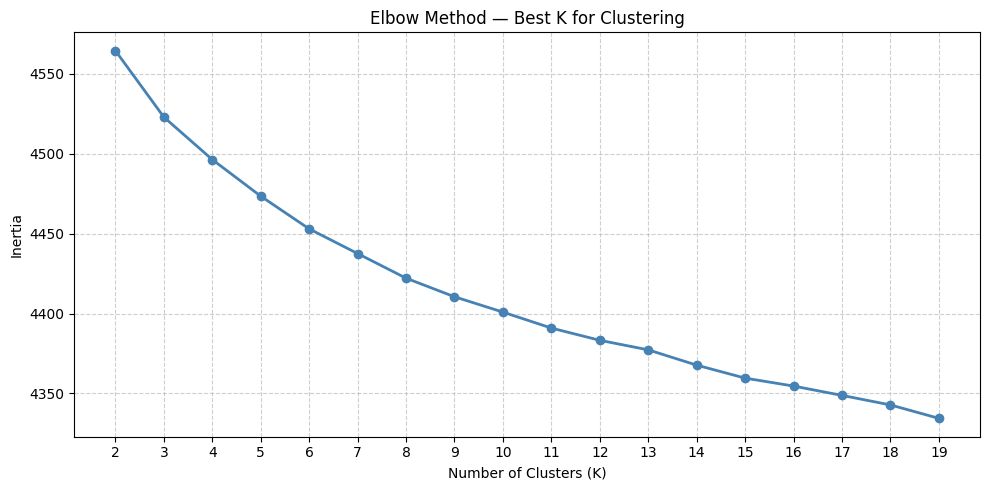


Applying K-Means with K=10...
Cluster distribution:
cluster
0    460
1    365
2    731
3    596
4    545
5    627
6    197
7    452
8    550
9    283
Name: count, dtype: int64


In [6]:
print("K-Means Clustering")

inertia_values = []
k_range = range(2, 20)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(vectors_normalized)
    inertia_values.append(km.inertia_)
    print(f"  K={k} → inertia={round(km.inertia_, 2)}")

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), inertia_values, marker='o',
         color='steelblue', linewidth=2)
plt.title('Elbow Method — Best K for Clustering')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(list(k_range))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('output/elbow_curve.png')
plt.show()

BEST_K = 10
print(f"\nApplying K-Means with K={BEST_K}...")
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
kmeans.fit(vectors_normalized)
final_df['cluster'] = kmeans.labels_

print("Cluster distribution:")
print(final_df['cluster'].value_counts().sort_index())

# PCA (Dimensionality Reduction)
--------------------------------------

PCA — Reducing to 2D
Variance explained — PC1: 1.65%
Variance explained — PC2: 1.49%
Total preserved:          3.14%


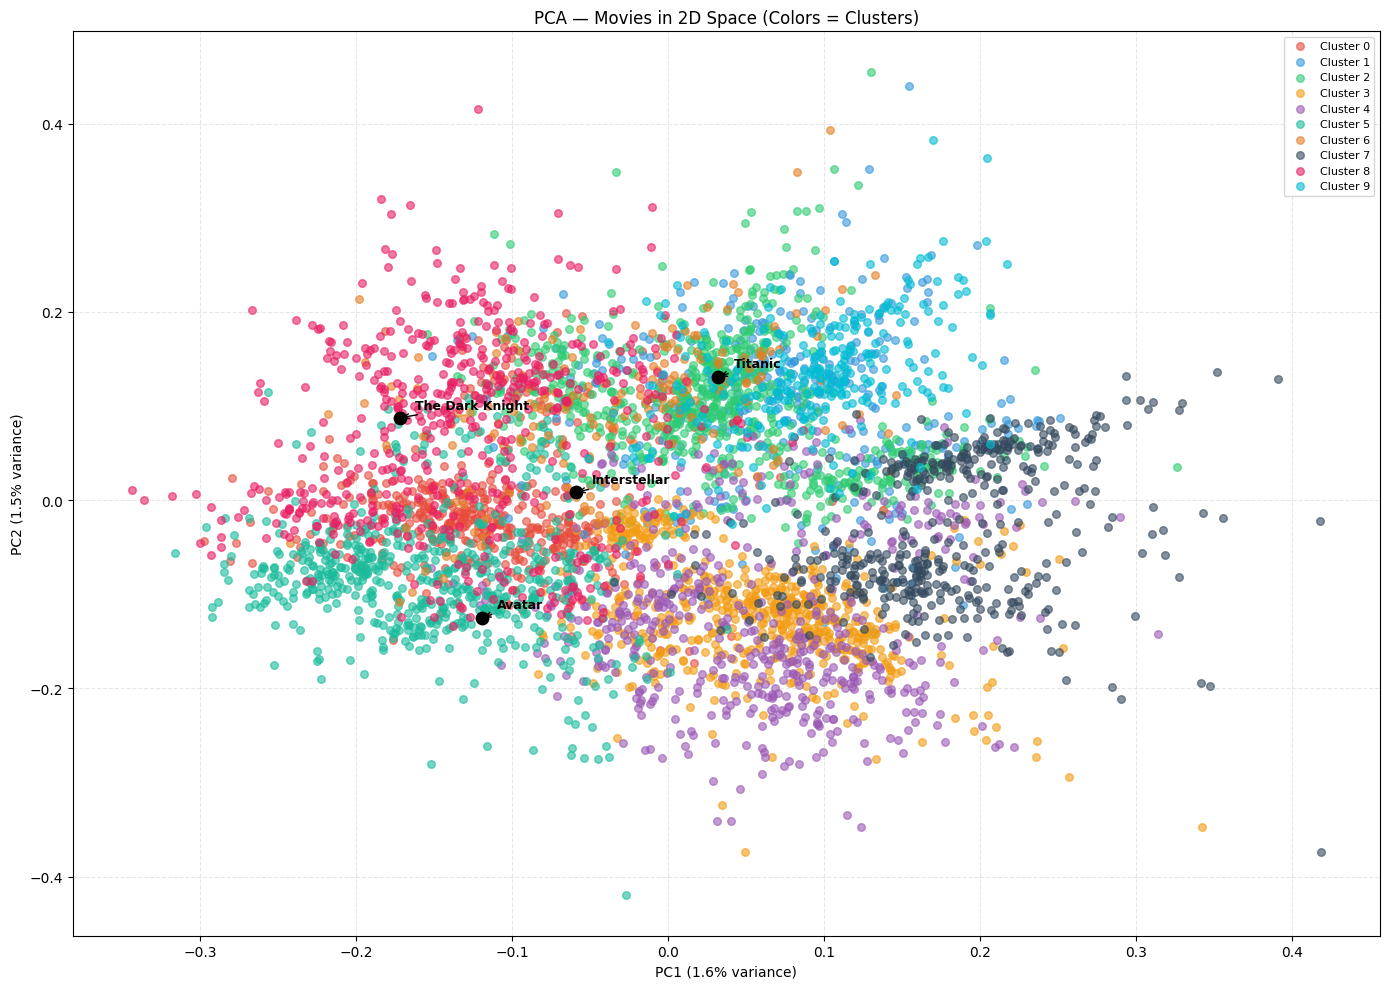

PCA plot saved!


In [7]:
print("PCA — Reducing to 2D")

pca = PCA(n_components=2, random_state=42)
vectors_2d  = pca.fit_transform(vectors_normalized)

explained = pca.explained_variance_ratio_
print(f"Variance explained — PC1: {round(explained[0]*100,2)}%")
print(f"Variance explained — PC2: {round(explained[1]*100,2)}%")
print(f"Total preserved:          {round(sum(explained)*100,2)}%")

final_df['pca_x'] = vectors_2d[:, 0]
final_df['pca_y'] = vectors_2d[:, 1]

colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6',
          '#1abc9c','#e67e22','#34495e','#e91e63','#00bcd4']

plt.figure(figsize=(14, 10))
for cid in range(BEST_K):
    mask = final_df['cluster'] == cid
    plt.scatter(final_df[mask]['pca_x'], final_df[mask]['pca_y'],
                c=colors[cid], label=f'Cluster {cid}', alpha=0.6, s=30)

for movie in ['Avatar','The Dark Knight','Titanic','Interstellar']:
    row = final_df[final_df['title'] == movie]
    if len(row) > 0:
        x, y = row['pca_x'].values[0], row['pca_y'].values[0]
        plt.annotate(movie, (x, y), fontsize=9, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color='black'),
                     xytext=(x+0.01, y+0.01))
        plt.scatter(x, y, c='black', s=80, zorder=5)

plt.title('PCA — Movies in 2D Space (Colors = Clusters)')
plt.xlabel(f'PC1 ({round(explained[0]*100,1)}% variance)')
plt.ylabel(f'PC2 ({round(explained[1]*100,1)}% variance)')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('output/pca_clusters.png', dpi=150)
plt.show()
print("PCA plot saved!")

# COSINE SIMILARITY (Main Recommendation Engine)
------------------------------------------------------

In [8]:
print("Building Cosine Similarity Matrix")

similarity = cosine_similarity(vectors_normalized)
print(f"Similarity matrix shape: {similarity.shape}")

Building Cosine Similarity Matrix
Similarity matrix shape: (4806, 4806)


# RECOMMENDATION FUNCTION
-------------------------------

In [9]:
print("Recommendation Function")

def recommend(movie_name):
    if movie_name not in final_df['title'].values:
        print(f"'{movie_name}' not found. Check spelling.")
        return

    idx             = final_df[final_df['title'] == movie_name].index[0]
    movie_cluster   = final_df.iloc[idx]['cluster']
    distances       = list(enumerate(similarity[idx]))
    sorted_movies   = sorted(distances, key=lambda x: x[1], reverse=True)

    print(f"\n{'='*55}")
    print(f"Movie : {movie_name}  |  Cluster: {movie_cluster}")
    print(f"{'='*55}")
    print(f"{'#':<4} {'Title':<38} {'Score':<8} {'Cluster'}")
    print("-" * 55)

    for i, (index, score) in enumerate(sorted_movies[1:6], 1):
        title   = final_df.iloc[index]['title']
        cluster = final_df.iloc[index]['cluster']
        tag     = "✅" if cluster == movie_cluster else "🔄"
        print(f"{i:<4} {title:<38} {round(score,4):<8} {tag} {cluster}")
    print("-" * 55)


Recommendation Function


In [10]:
# Test recommendations
recommend("Avatar")
recommend("The Dark Knight")
recommend("Interstellar")


Movie : Avatar  |  Cluster: 5
#    Title                                  Score    Cluster
-------------------------------------------------------
1    Titan A.E.                             0.2609   ✅ 5
2    Small Soldiers                         0.2582   ✅ 5
3    Ender's Game                           0.2511   ✅ 5
4    Aliens vs Predator: Requiem            0.2494   ✅ 5
5    Independence Day                       0.2485   ✅ 5
-------------------------------------------------------

Movie : The Dark Knight  |  Cluster: 8
#    Title                                  Score    Cluster
-------------------------------------------------------
1    The Dark Knight Rises                  0.4239   ✅ 8
2    Batman Begins                          0.3939   ✅ 8
3    Batman Returns                         0.3194   🔄 5
4    Batman Forever                         0.2901   ✅ 8
5    Batman & Robin                         0.2817   ✅ 8
-------------------------------------------------------

Movie : Inte

# LINEAR REGRESSION
----------------------------

Linear Regression — Predict Movie Rating
RMSE: 0.7022
R²  : 0.3556


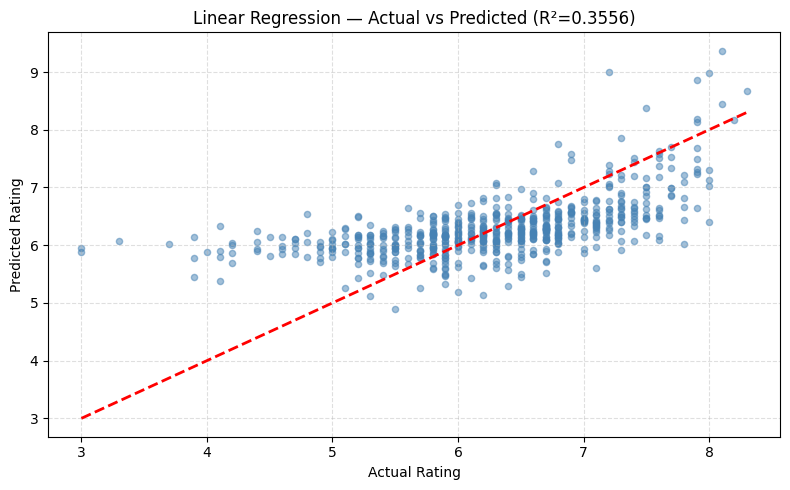

Regression chart saved!


In [11]:
print("Linear Regression — Predict Movie Rating")

reg_data = movies_raw[['budget','revenue','runtime',
                        'popularity','vote_average','vote_count']].copy()
reg_data = reg_data[
    (reg_data['budget']     > 0) &
    (reg_data['revenue']    > 0) &
    (reg_data['runtime']    > 0) &
    (reg_data['vote_count'] > 10)
].dropna()

X = reg_data[['budget','revenue','runtime','popularity','vote_count']]
y = reg_data['vote_average']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred   = lr_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f"RMSE: {round(rmse,4)}")
print(f"R²  : {round(r2,4)}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=20)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title(f'Linear Regression — Actual vs Predicted (R²={round(r2,4)})')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('output/regression_results.png')
plt.show()
print("Regression chart saved!")

# ASSOCIATION RULE MINING
------------------------------

Association Rule Mining
Rules found: 16

Top 10 Rules:
----------------------------------------------------------------------
IF [Mystery] THEN [Thriller]  sup=0.051  conf=0.695  lift=2.606
IF [Adventure] THEN [Action]  sup=0.097  conf=0.589  lift=2.436
IF [Action] THEN [Adventure]  sup=0.097  conf=0.403  lift=2.436
IF [Thriller] THEN [Crime]  sup=0.087  conf=0.325  lift=2.229
IF [Crime] THEN [Thriller]  sup=0.087  conf=0.595  lift=2.229
IF [Science Fiction] THEN [Action]  sup=0.058  conf=0.518  lift=2.142
IF [Horror] THEN [Thriller]  sup=0.061  conf=0.561  lift=2.102
IF [Action] THEN [Thriller]  sup=0.115  conf=0.474  lift=1.777
IF [Thriller] THEN [Action]  sup=0.115  conf=0.429  lift=1.777
IF [Crime] THEN [Action]  sup=0.058  conf=0.397  lift=1.641


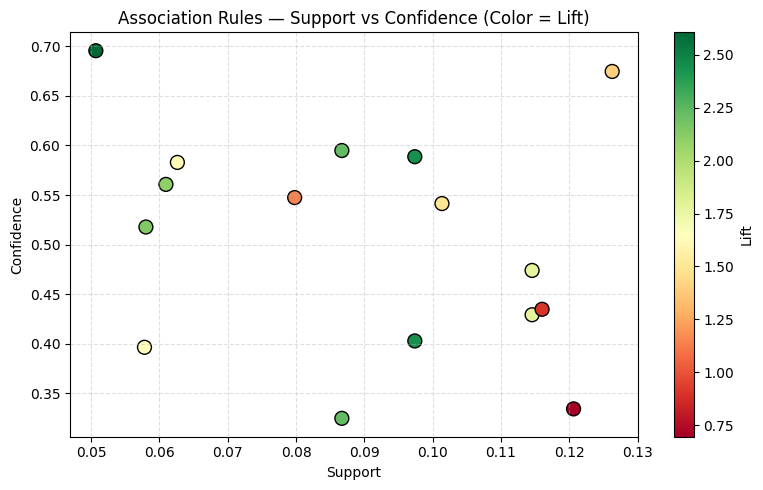

Association rules chart saved!


In [12]:
print("Association Rule Mining")


movies_raw['genres_list'] = movies_raw['genres'].apply(
    lambda x: [item['name'] for item in ast.literal_eval(x)]
    if pd.notna(x) else []
)

genre_transactions = movies_raw['genres_list'][
    movies_raw['genres_list'].apply(len) > 0
].tolist()

te       = TransactionEncoder()
te_array = te.fit_transform(genre_transactions)
genre_df = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(genre_df, min_support=0.05,
                             use_colnames=True, max_len=3)

rules = association_rules(frequent_itemsets,
                          metric='confidence', min_threshold=0.3)
rules = rules.sort_values('lift', ascending=False)

print(f"Rules found: {len(rules)}")
print("\nTop 10 Rules:")
print("-" * 70)
for _, row in rules.head(10).iterrows():
    a = ', '.join(list(row['antecedents']))
    c = ', '.join(list(row['consequents']))
    print(f"IF [{a}] THEN [{c}]  "
          f"sup={round(row['support'],3)}  "
          f"conf={round(row['confidence'],3)}  "
          f"lift={round(row['lift'],3)}")

plt.figure(figsize=(8, 5))
plt.scatter(rules['support'], rules['confidence'],
            c=rules['lift'], cmap='RdYlGn', s=100, edgecolors='black')
plt.colorbar(label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules — Support vs Confidence (Color = Lift)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('output/association_rules.png')
plt.show()
print("Association rules chart saved!")

# STAR SCHEMA
------------------------

In [13]:
print("Star Schema — Creating Dimension Tables")

all_genres = []
for _, row in movies_raw.iterrows():
    try:
        for g in ast.literal_eval(row['genres']):
            all_genres.append({'genre_id': g['id'], 'genre_name': g['name']})
    except:
        pass

dim_genre = (pd.DataFrame(all_genres)
               .drop_duplicates('genre_id')
               .reset_index(drop=True))

# DIM_DIRECTOR
all_directors = []
for _, row in credits.iterrows():
    try:
        for p in ast.literal_eval(row['crew']):
            if p['job'] == 'Director':
                all_directors.append({
                    'director_id':   p['id'],
                    'director_name': p['name']
                })
    except:
        pass

dim_director = (pd.DataFrame(all_directors)
                  .drop_duplicates('director_id')
                  .reset_index(drop=True))

# DIM_DATE
movies_raw['release_date'] = pd.to_datetime(
    movies_raw['release_date'], errors='coerce')

dim_date             = movies_raw[['release_date']].dropna().drop_duplicates().copy()
dim_date['date_id']  = range(1, len(dim_date)+1)
dim_date['year']     = dim_date['release_date'].dt.year
dim_date['month']    = dim_date['release_date'].dt.month
dim_date['quarter']  = dim_date['release_date'].dt.quarter

# FACT TABLE
fact_movies = movies_raw[['id','title','budget','revenue',
                           'runtime','vote_average',
                           'vote_count','popularity']].copy()
fact_movies.rename(columns={'id':'movie_id'}, inplace=True)
fact_movies['profit'] = fact_movies['revenue'] - fact_movies['budget']

# Save tables
dim_genre.to_csv('output/dim_genre.csv',       index=False)
dim_director.to_csv('output/dim_director.csv', index=False)
dim_date.to_csv('output/dim_date.csv',         index=False)
fact_movies.to_csv('output/fact_movies.csv',   index=False)

print("Star Schema tables saved:")
print(f"  dim_genre     → {len(dim_genre)} genres")
print(f"  dim_director  → {len(dim_director)} directors")
print(f"  dim_date      → {len(dim_date)} dates")
print(f"  fact_movies   → {len(fact_movies)} movies")


Star Schema — Creating Dimension Tables
Star Schema tables saved:
  dim_genre     → 20 genres
  dim_director  → 2578 directors
  dim_date      → 3280 dates
  fact_movies   → 4803 movies


# DECISION TREE
----------------------------

Decision Tree Classifier
Accuracy: 75.79%

Classification Report:
              precision    recall  f1-score   support

     Average       0.78      0.93      0.85       465
        Good       0.60      0.39      0.47       126
        Poor       0.00      0.00      0.00        45

    accuracy                           0.76       636
   macro avg       0.46      0.44      0.44       636
weighted avg       0.69      0.76      0.71       636



C:\Users\yashr\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yashr\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yashr\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


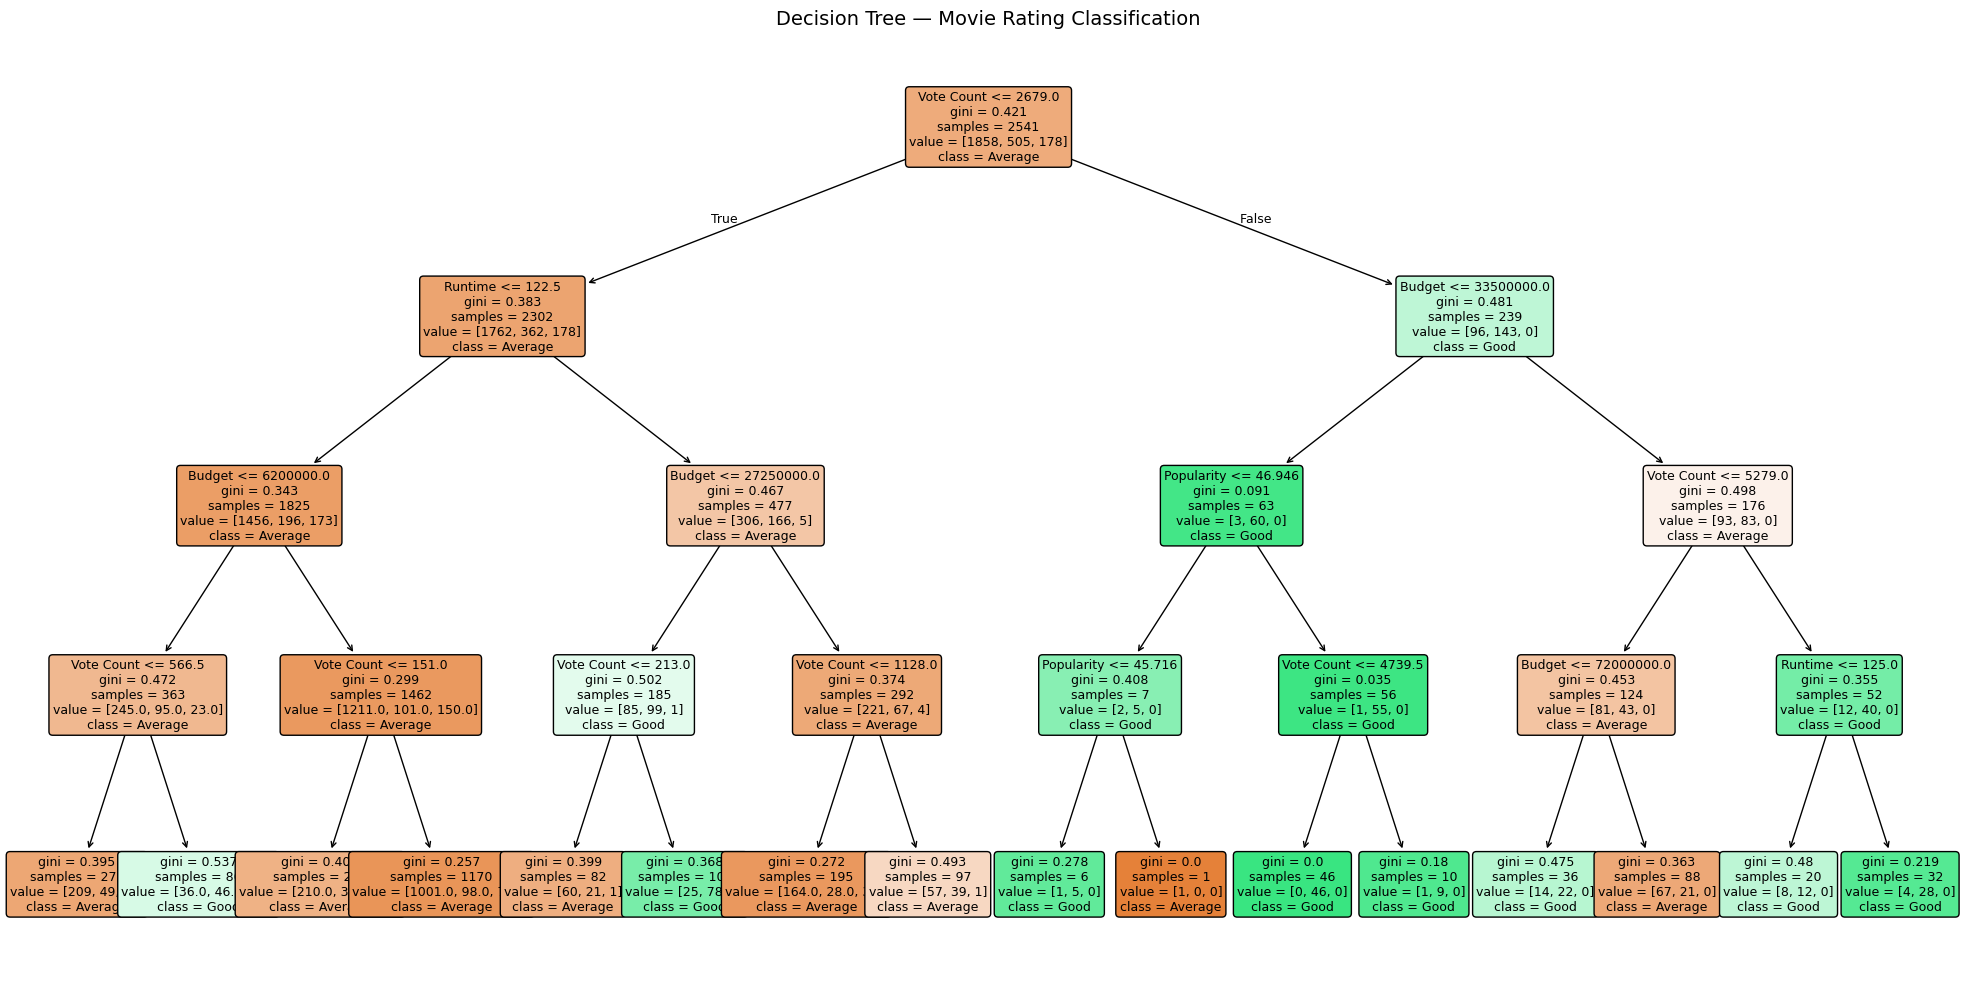

Decision tree chart saved!


In [14]:
print("Decision Tree Classifier")

dt_data = movies_raw[['budget','revenue','runtime',
                       'popularity','vote_count','vote_average']].copy()
dt_data = dt_data[
    (dt_data['budget']     > 0) &
    (dt_data['revenue']    > 0) &
    (dt_data['runtime']    > 0) &
    (dt_data['vote_count'] > 10)
].dropna()

dt_data['rating_category'] = pd.cut(
    dt_data['vote_average'],
    bins=[0, 5.0, 7.0, 10.0],
    labels=['Poor','Average','Good']
)
dt_data.dropna(subset=['rating_category'], inplace=True)

X  = dt_data[['budget','revenue','runtime','popularity','vote_count']]
y  = dt_data['rating_category']
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

dt_model = DecisionTreeClassifier(max_depth=4,
                                   random_state=42,
                                   criterion='gini')
dt_model.fit(X_train, y_train)
y_pred   = dt_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {round(acc*100, 2)}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

feature_names = ['Budget','Revenue','Runtime','Popularity','Vote Count']

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=feature_names,
          class_names=le.classes_, filled=True,
          rounded=True, fontsize=9)
plt.title('Decision Tree — Movie Rating Classification', fontsize=14)
plt.tight_layout()
plt.savefig('output/decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Decision tree chart saved!")

In [15]:
#  SAVE ALL MODEL FILES

print("STEP 16: Saving All Model Files")
print("="*60)

pickle.dump(final_df,           open('output/movies.pkl',     'wb'))
pickle.dump(similarity,         open('output/similarity.pkl', 'wb'))
pickle.dump(vectors_normalized, open('output/vectors.pkl',    'wb'))
pickle.dump(kmeans,             open('output/kmeans.pkl',     'wb'))

print("✅ movies.pkl     saved")
print("✅ similarity.pkl saved")
print("✅ vectors.pkl    saved")
print("✅ kmeans.pkl     saved")

STEP 16: Saving All Model Files
✅ movies.pkl     saved
✅ similarity.pkl saved
✅ vectors.pkl    saved
✅ kmeans.pkl     saved


# Evaluation

In [22]:
# # ── Step 9: Simple Evaluation ──────────────────────────────────────────────────

# def evaluate_recommendations(movie_name):
#     """
#     Simple evaluation:
#     - Show the genres of the input movie
#     - Show the genres of recommended movies
#     - Check if genres overlap (common sense evaluation)
#     """
    
#     if movie_name not in movies['title'].values:
#         print("Movie not found.")
#         return
    
#     # Get genres of the input movie
#     input_genres = movies[movies['title'] == movie_name]['genres'].values[0]
#     print(f"\nInput Movie: {movie_name}")
#     print(f"Genres: {input_genres}")
    
#     # Get recommendations
#     movie_index = final_df[final_df['title'] == movie_name].index[0]
#     distances = list(enumerate(similarity[movie_index]))
#     sorted_movies = sorted(distances, key=lambda x: x[1], reverse=True)
    
#     print(f"\nRecommended Movies and their genres:")
#     print("-" * 50)
    
#     match_count = 0
#     for index, score in sorted_movies[1:6]:
#         rec_title = final_df.iloc[index]['title']
#         rec_genres = movies[movies['title'] == rec_title]['genres'].values
        
#         if len(rec_genres) > 0:
#             rec_genres = rec_genres[0]
#             # Check how many genres match
#             common_genres = set(input_genres) & set(rec_genres)
#             if common_genres:
#                 match_count += 1
#             print(f"  {rec_title}")
#             print(f"  Genres: {rec_genres}")
#             print(f"  Common genres with input: {list(common_genres)}")
#             print()
    
#     print(f"Genre Match Rate: {match_count}/5 recommendations share at least one genre")

# # Test evaluation
# evaluate_recommendations("Avatar")

In [23]:
# # ── Step 10: Visualizations ────────────────────────────────────────────────────

# import matplotlib.pyplot as plt
# from collections import Counter

# # ── Chart 1: Most Common Genres in Dataset ────────────────────────────────────

# # Flatten all genres from all movies into one big list
# all_genres = []
# for genre_list in movies['genres']:
#     all_genres.extend(genre_list)

# # Count frequency of each genre
# genre_counts = Counter(all_genres)

# # Get top 10 genres
# top_genres = genre_counts.most_common(10)
# genre_names = [g[0] for g in top_genres]
# genre_freq  = [g[1] for g in top_genres]

# # Plot
# plt.figure(figsize=(12, 5))
# plt.bar(genre_names, genre_freq, color='steelblue', edgecolor='black')
# plt.title('Top 10 Most Common Movie Genres in Dataset', fontsize=14)
# plt.xlabel('Genre')
# plt.ylabel('Number of Movies')
# plt.xticks(rotation=30, ha='right')
# plt.tight_layout()
# plt.savefig('output/genre_distribution.png')  # Save chart
# plt.show()
# print("Chart 1 saved.")

# # ── Chart 2: Similarity Score Distribution for One Movie ──────────────────────

# movie_to_check = "Avatar"
# movie_index = final_df[final_df['title'] == movie_to_check].index[0]
# scores = similarity[movie_index]

# plt.figure(figsize=(10, 4))
# plt.hist(scores, bins=50, color='coral', edgecolor='black')
# plt.title(f'Similarity Score Distribution for "{movie_to_check}"', fontsize=14)
# plt.xlabel('Cosine Similarity Score')
# plt.ylabel('Number of Movies')
# plt.tight_layout()
# plt.savefig('output/similarity_distribution.png')
# plt.show()
# print("Chart 2 saved.")

# # ── Chart 3: Top 5 Recommended Movies — Similarity Bar Chart ──────────────────

# def plot_recommendations(movie_name):
#     if movie_name not in final_df['title'].values:
#         print("Movie not found.")
#         return
    
#     movie_index = final_df[final_df['title'] == movie_name].index[0]
#     distances = list(enumerate(similarity[movie_index]))
#     sorted_movies = sorted(distances, key=lambda x: x[1], reverse=True)[1:6]
    
#     titles = [final_df.iloc[i]['title'] for i, _ in sorted_movies]
#     scores = [round(s, 4) for _, s in sorted_movies]
    
#     plt.figure(figsize=(10, 5))
#     plt.barh(titles[::-1], scores[::-1], color='mediumseagreen', edgecolor='black')
#     plt.title(f'Top 5 Movies Similar to "{movie_name}"', fontsize=14)
#     plt.xlabel('Cosine Similarity Score')
#     plt.tight_layout()
#     plt.savefig(f'output/recommendations_{movie_name.replace(" ", "_")}.png')
#     plt.show()
#     print(f"Chart saved for {movie_name}")

# plot_recommendations("Avatar")
# plot_recommendations("The Dark Knight")